- In this notebook: testing flare plotting function

In [66]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time

import pandas as pd

In [ ]:
#using large flare from last week

In [154]:
lf_query = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

lf_file = Fido.fetch(lf_query)

lf_lc = ts.TimeSeries(lf_file)

lf_df = lf_lc.to_dataframe()
lf_df.columns

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Index(['control_index', 'timedel', 'triggers', 'triggers_comp_err', 'rcr',
       '4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV',
       '4-10 keV_comp_err', '10-15 keV_comp_err', '15-25 keV_comp_err',
       '25-50 keV_comp_err', '50-84 keV_comp_err'],
      dtype='str')

In [10]:
goes_lf_result = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))

goes_lf_files = Fido.fetch(goes_lf_result)

goes_lf = ts.TimeSeries(goes_lf_files, concatenate=True)

goes_lf_df = goes_lf.to_dataframe()
goes_lf_df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2024-10-03 00:00:00.000000,8.273804e-08,0.000005,0,0,NaN,NaN
2024-10-03 00:00:00.148189,8.235878e-08,0.000005,0,0,1.0,1.0
2024-10-03 00:00:01.148191,9.100413e-08,0.000005,0,0,1.0,1.0
2024-10-03 00:00:02.148196,8.775229e-08,0.000005,0,0,1.0,1.0
2024-10-03 00:00:03.148199,8.667359e-08,0.000005,0,0,1.0,1.0
...,...,...,...,...,...,...
2024-10-03 23:59:55.389386,2.116607e-07,0.000008,0,0,1.0,1.0
2024-10-03 23:59:56.389395,2.148809e-07,0.000008,0,0,1.0,1.0
2024-10-03 23:59:57.389397,2.235105e-07,0.000008,0,0,1.0,1.0
2024-10-03 23:59:58.389400,2.213690e-07,0.000008,0,0,1.0,1.0


<Axes: >

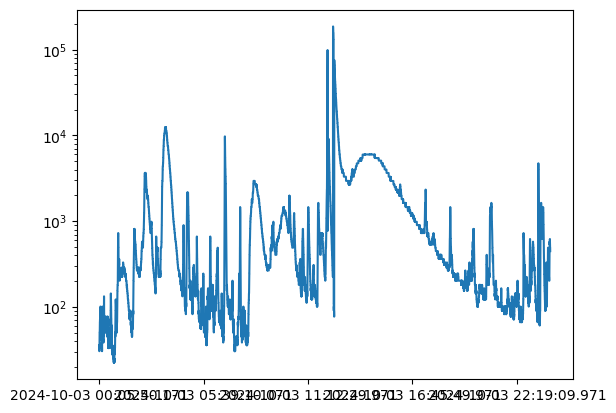

In [105]:
fig, ax = plt.subplots()
lf_df['4-10 keV'].plot(logy=True)
#lf_df.plot(axes=ax, columns = ['4-10 keV'])

<Axes: title={'center': 'STIX QL Light Curve'}, ylabel='ct / (keV s)'>

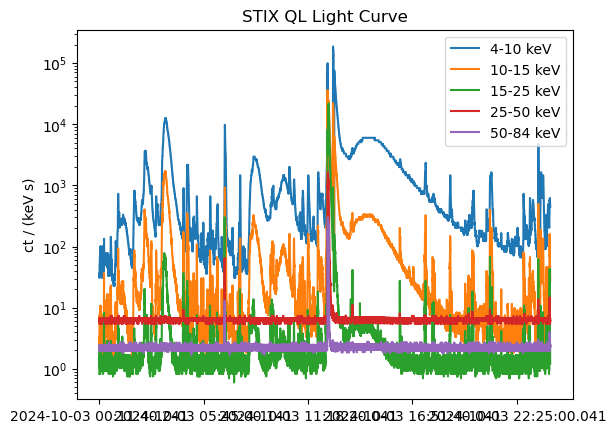

In [83]:
lf_lc.plot()
#plt.xlim(datetime(2024, 10, 3, 11, 50), datetime(2024, 10, 3, 12, 50))

In [17]:
lf_lc.units

OrderedDict([('control_index', None),
             ('timedel', Unit("cs")),
             ('triggers', None),
             ('triggers_comp_err', None),
             ('rcr', None),
             ('4-10 keV', Unit("ct / (keV s)")),
             ('10-15 keV', Unit("ct / (keV s)")),
             ('15-25 keV', Unit("ct / (keV s)")),
             ('25-50 keV', Unit("ct / (keV s)")),
             ('50-84 keV', Unit("ct / (keV s)")),
             ('4-10 keV_comp_err', Unit("ct / (keV s)")),
             ('10-15 keV_comp_err', Unit("ct / (keV s)")),
             ('15-25 keV_comp_err', Unit("ct / (keV s)")),
             ('25-50 keV_comp_err', Unit("ct / (keV s)")),
             ('50-84 keV_comp_err', Unit("ct / (keV s)"))])

<Axes: ylabel='Watts m$^{-2}$'>

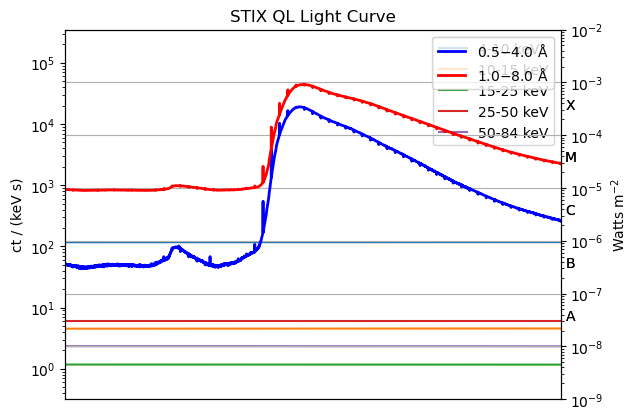

In [152]:
fig, ax = plt.subplots()
ax.set_yscale('log')
lf_lc.plot(axes=ax, columns = ['4-10 keV'])
lf_lc.plot(axes=ax, columns = ['10-15 keV'])
lf_lc.plot(axes=ax, columns = ['15-25 keV'])
lf_lc.plot(axes=ax, columns = ['25-50 keV'])
lf_lc.plot(axes=ax, columns = ['50-84 keV'])
plt.xlim(datetime(2024, 10, 3, 11, 50), datetime(2024, 10, 3, 12, 50))

goes_ax = ax.twinx()
goes_lf.plot(axes=goes_ax, columns =['xrsa'])
goes_lf.plot(axes=goes_ax, columns =['xrsb'])

In [85]:
earth_tdel = lf_lc.meta.metas[0]["EAR_TDEL"]
earth_tdel

350.0694317006763

In [72]:
lf_df['4-10 keV']

time
2024-10-03 00:00:00.102     35.980337
2024-10-03 00:00:04.102     33.313670
2024-10-03 00:00:08.102     33.312038
2024-10-03 00:00:12.102     30.643740
2024-10-03 00:00:16.102     33.312038
                              ...    
2024-10-03 23:59:39.902    492.263052
2024-10-03 23:59:43.902    492.118071
2024-10-03 23:59:47.902    449.321561
2024-10-03 23:59:51.902    449.233356
2024-10-03 23:59:55.902    449.233356
Name: 4-10 keV, Length: 21600, dtype: float64

In [88]:
lf_lc.time

<Time object: scale='utc' format='iso' value=['2024-10-03 00:00:00.102' '2024-10-03 00:00:04.102'
 '2024-10-03 00:00:08.102' ... '2024-10-03 23:59:47.902'
 '2024-10-03 23:59:51.902' '2024-10-03 23:59:55.902']>

In [90]:
updated_times

<Time object: scale='utc' format='iso' value=['2024-10-03 00:05:50.171' '2024-10-03 00:05:54.171'
 '2024-10-03 00:05:58.171' ... '2024-10-04 00:05:37.971'
 '2024-10-04 00:05:41.971' '2024-10-04 00:05:45.971']>

In [91]:
updated_times = lf_lc.time+dt.timedelta(seconds=earth_tdel)
#new_lf_df = pd.DataFrame(data=(lf_df['4-10 keV'], lf_df['10-15 keV'], lf_df['15-25 keV'], lf_df['25-50 keV'], lf_df['50-84 keV']), index=updated_times, columns=(['4-10 keV'], ['10-15 keV'], ['15-25 keV'], ['25-50 keV'], ['50-84 keV']))

# lf_df['4-10 keV'].index = updated_times
# new_lf_df = pd.DataFrame(data=lf_df['4-10 keV'], index=updated_times, columns=['4-10 keV']) 
# new_lf_df

lf_df.index = updated_times
lf_df

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
2024-10-03 00:05:50.171,0,400.0,3199,73.901962,0,35.980337,3.352050,0.825505,6.073714,2.229304,18.479719,2.345208,1.224745,18.479719,9.246621
2024-10-03 00:05:54.171,0,400.0,3455,73.901962,0,33.313670,3.352214,1.526008,6.714435,2.464863,18.479719,2.345208,1.224745,18.479719,9.246621
2024-10-03 00:05:58.171,0,400.0,3199,73.901962,0,33.312038,2.851744,1.325811,6.073714,2.229304,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-03 00:06:02.171,0,400.0,3199,73.901962,0,30.643740,3.051866,1.325811,6.073714,2.229304,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-03 00:06:06.171,0,400.0,3199,73.901962,0,33.312038,3.051866,1.025627,6.714106,2.464743,18.479719,1.224745,1.224745,18.479719,9.246621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-04 00:05:29.971,38,400.0,17407,591.206787,0,492.263052,36.872697,2.081928,6.732403,2.235380,295.603607,18.479719,2.345208,18.479719,9.246621
2024-10-04 00:05:33.971,38,400.0,15871,295.603607,0,492.118071,33.652099,1.529641,6.088472,2.470731,295.603607,18.479719,1.224745,18.479719,9.246621
2024-10-04 00:05:37.971,38,400.0,15871,295.603607,0,449.321561,33.652099,1.529641,6.088472,2.234721,295.603607,18.479719,1.224745,18.479719,9.246621
2024-10-04 00:05:41.971,38,400.0,14847,295.603607,0,449.233356,30.436385,1.880337,6.087277,2.470246,295.603607,18.479719,2.345208,18.479719,9.246621


In [74]:
lf_df['4-10 keV']

time
2024-10-03 00:00:00.102     35.980337
2024-10-03 00:00:04.102     33.313670
2024-10-03 00:00:08.102     33.312038
2024-10-03 00:00:12.102     30.643740
2024-10-03 00:00:16.102     33.312038
                              ...    
2024-10-03 23:59:39.902    492.263052
2024-10-03 23:59:43.902    492.118071
2024-10-03 23:59:47.902    449.321561
2024-10-03 23:59:51.902    449.233356
2024-10-03 23:59:55.902    449.233356
Name: 4-10 keV, Length: 21600, dtype: float64

In [43]:
lf_df.columns

Index(['control_index', 'timedel', 'triggers', 'triggers_comp_err', 'rcr',
       '4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV',
       '4-10 keV_comp_err', '10-15 keV_comp_err', '15-25 keV_comp_err',
       '25-50 keV_comp_err', '50-84 keV_comp_err'],
      dtype='str')

In [75]:
#lf_df.reset_index()

In [93]:
lf_lc.units

OrderedDict([('control_index', None),
             ('timedel', Unit("cs")),
             ('triggers', None),
             ('triggers_comp_err', None),
             ('rcr', None),
             ('4-10 keV', Unit("ct / (keV s)")),
             ('10-15 keV', Unit("ct / (keV s)")),
             ('15-25 keV', Unit("ct / (keV s)")),
             ('25-50 keV', Unit("ct / (keV s)")),
             ('50-84 keV', Unit("ct / (keV s)")),
             ('4-10 keV_comp_err', Unit("ct / (keV s)")),
             ('10-15 keV_comp_err', Unit("ct / (keV s)")),
             ('15-25 keV_comp_err', Unit("ct / (keV s)")),
             ('25-50 keV_comp_err', Unit("ct / (keV s)")),
             ('50-84 keV_comp_err', Unit("ct / (keV s)"))])

In [95]:
lf_410 = ts.TimeSeries(lf_df)

<Axes: ylabel='Watts m$^{-2}$'>

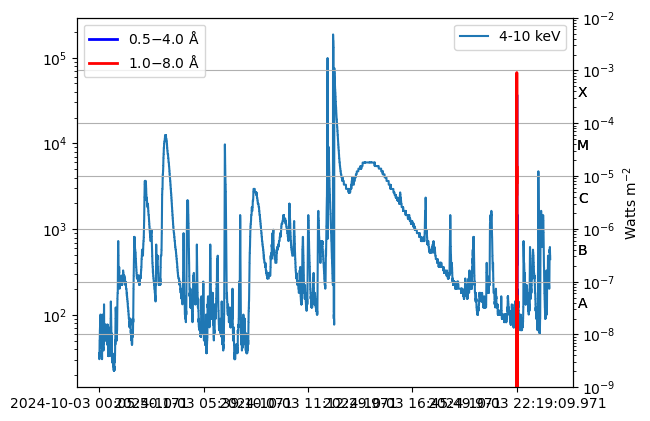

In [98]:
fig, ax = plt.subplots()
ax.set_yscale('log')
lf_410.plot(axes=ax, columns = ['4-10 keV'])

goes_ax = ax.twinx()
goes_lf.plot(axes=goes_ax, columns =['xrsa'])
goes_lf.plot(axes=goes_ax, columns =['xrsb'])

In [99]:
lf_lc.meta

|-------------------------------------------------------------------------------------------------|
|TimeRange                  | Columns         | Meta                                              |
|-------------------------------------------------------------------------------------------------|
|2024-10-03T00:00:00.102000 | control_index   | simple: True                                      |
|            to             | timedel         | bitpix: 8                                         |
|2024-10-03T23:59:55.902000 | triggers        | naxis: 0                                          |
|                           | triggers_comp_e | extend: True                                      |
|                           | rcr             | filename: solo_L1_stix-ql-lightcurve_20241003_V02.|
|                           | 4-10 keV        | raw_file: TM_hourly_req_BatchRequest.PktTmRaw.SOL.|
|                           | 10-15 keV       | parent: solo_L0_stix-ql-lightcurve_0781142400_V02.|


In [ ]:
# for value in lf_df['rcr']:
#     if value != 0:
#         shade = True
#     elif value == 0:
#         shade = False 

In [132]:
lf_query = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

lf_file = Fido.fetch(lf_query)

lf_lc = ts.TimeSeries(lf_file)
lf_df = lf_lc.to_dataframe()

#lf_lc_trunc.plot()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [116]:
goes_lf_result = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))

goes_lf_files = Fido.fetch(goes_lf_result)

goes_lf = ts.TimeSeries(goes_lf_files, concatenate=True)
goes_lf_trunc = goes_lf.truncate('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992')
goes_lf_df = goes_lf_trunc.to_dataframe()
goes_lf_df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2024-10-03 12:04:30.269102,6.244113e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:31.269106,6.200805e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:32.269105,6.136241e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:33.269112,6.179390e-07,0.000011,0,0,1.0,1.0
2024-10-03 12:04:34.269112,6.168443e-07,0.000011,0,0,1.0,1.0
...,...,...,...,...,...,...
2024-10-03 13:15:37.281012,1.008097e-06,0.000015,0,0,1.0,1.0
2024-10-03 13:15:38.281014,9.875849e-07,0.000015,0,0,1.0,1.0
2024-10-03 13:15:39.281021,1.022120e-06,0.000015,0,0,1.0,1.0
2024-10-03 13:15:40.281020,1.004861e-06,0.000015,0,0,1.0,1.0


In [127]:
lf_df

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
time,,,,,,,,,,,,,,,
2024-10-03 12:04:31.902,20,400.0,23551,591.206787,0,728.571760,80.311570,3.390263,6.097451,2.474375,591.206787,36.952671,4.636809,18.479719,9.246621
2024-10-03 12:04:35.902,20,400.0,23551,591.206787,0,728.571760,73.882626,3.390263,6.740346,2.238017,591.206787,36.952671,4.636809,18.479719,9.246621
2024-10-03 12:04:39.902,20,400.0,23551,591.206787,0,728.571760,73.882626,2.888002,6.097451,2.001659,591.206787,36.952671,2.345208,18.479719,9.246621
2024-10-03 12:04:43.902,20,400.0,25599,591.206787,0,728.858396,80.343166,2.889138,6.742997,2.238897,591.206787,36.952671,2.345208,18.479719,9.246621
2024-10-03 12:04:47.902,20,400.0,25599,591.206787,0,814.611368,73.911693,2.889138,6.099850,2.475349,591.206787,36.952671,2.345208,18.479719,9.246621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-03 13:15:23.902,22,400.0,86015,2364.826660,0,2949.792741,136.595937,3.126405,6.171473,2.265186,2364.826660,73.901962,2.345208,18.479719,9.246621
2024-10-03 13:15:27.902,22,400.0,86015,2364.826660,0,2949.792741,136.595937,3.838107,6.171473,2.265186,2364.826660,73.901962,4.636809,18.479719,9.246621
2024-10-03 13:15:31.902,22,400.0,86015,2364.826660,0,2949.792741,149.609916,3.431420,6.171473,2.265186,2364.826660,73.901962,4.636809,18.479719,9.246621


In [138]:
shifted_times[0]

<Time object: scale='utc' format='iso' value=2024-10-03 12:16:12.041>

In [148]:
earth_tdel = lf_lc.meta.metas[0]["EAR_TDEL"]
shifted_times = lf_lc.time+dt.timedelta(seconds=earth_tdel)
lf_df.index = shifted_times

tstart = parse_time('2024-10-03T12:04:29.984')
tstart_s = tstart+dt.timedelta(seconds=earth_tdel)

tend = parse_time('2024-10-03T13:15:41.992')
tend_s = tend+dt.timedelta(seconds=earth_tdel)

from sunpy.time import TimeRange
tr=TimeRange(tstart_s, tend_s)

In [149]:
lf_lc_f = ts.TimeSeries(lf_df)
lf_lc_trunc = lf_lc_f.truncate(tr)

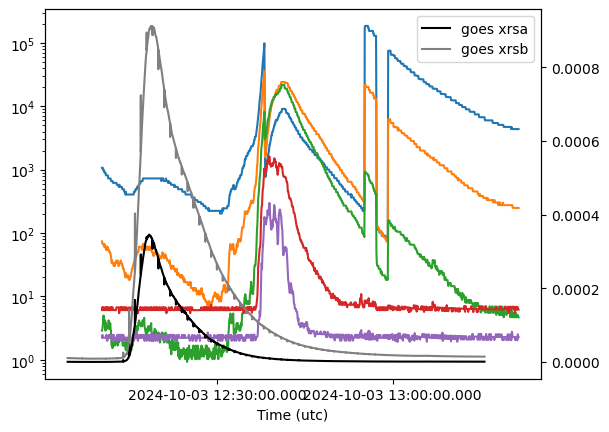

In [150]:
time_support()
fig, ax = plt.subplots()
ax.set_yscale('log')

ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('4-10 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('10-15 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('15-25 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('25-50 keV'))
ax.plot(lf_lc_trunc.time, lf_lc_trunc.quantity('50-84 keV'))

goes_ax = ax.twinx()
goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsa'), label = 'goes xrsa', color = 'black')
goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsb'), label = 'goes xrsb', color='gray')
goes_ax.legend()

In [153]:
# time_support()
# fig, ax = plt.subplots()
# ax.set_yscale('log')

# ax.plot(lf_lc_f.time, lf_lc_f.quantity('4-10 keV'))
# ax.plot(lf_lc_f.time, lf_lc_f.quantity('10-15 keV'))
# ax.plot(lf_lc_f.time, lf_lc_f.quantity('15-25 keV'))
# ax.plot(lf_lc_f.time, lf_lc_f.quantity('25-50 keV'))
# ax.plot(lf_lc_f.time, lf_lc_f.quantity('50-84 keV'))

# goes_ax = ax.twinx()
# goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsa'), label = 'goes xrsa', color = 'black')
# goes_ax.plot(goes_lf_trunc.time, goes_lf_trunc.quantity('xrsb'), label = 'goes xrsb', color='gray')
# goes_ax.legend()